# Formative 2, Task 2: Image Data Processing and Facial Recognition

**Author:** David Akintoya. 

This notebook builds the image pipeline: load team photos, detect and crop faces, augment them, extract features, and train a facial recognition model.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog
%matplotlib inline

In [2]:
TEAM_MEMBERS = ["David", "Bakhit", "Divine", "Serein"]
IMAGES_DIR = "../images"
EXPRESSIONS = ["neutral", "smiling", "surprised"]
RANDOM_SEED = 42

def find_image(member, expression):
    for ext in ("jpg", "png"):
        path = f"{IMAGES_DIR}/{member}/{expression}.{ext}"
        if os.path.exists(path):
            return path
    return None

member_images = {}
for name in TEAM_MEMBERS:
    member_images[name] = {expr: find_image(name, expr) for expr in EXPRESSIONS}
    found = sum(1 for p in member_images[name].values() if p is not None)
    print(f"{name}: {found}/{len(EXPRESSIONS)} images found")

unauthorized_path = None
for ext in ("jpg", "png"):
    p = f"{IMAGES_DIR}/unauthorized/attempt1.{ext}"
    if os.path.exists(p):
        unauthorized_path = p
        break
print(f"unauthorized: {'found' if unauthorized_path else 'missing'} ({unauthorized_path})")

total_found = sum(1 for m in TEAM_MEMBERS for e in EXPRESSIONS if member_images[m][e] is not None)
print(f"total: {total_found}/12 required photos found")
assert total_found == 12, "expected all 12 member photos to be present"

David: 3/3 images found
Bakhit: 3/3 images found
Divine: 3/3 images found
Serein: 3/3 images found
unauthorized: found (../images/unauthorized/attempt1.jpg)
total: 12/12 required photos found


## 1. Load and Display Team Photos

David/neutral: shape=(3264, 2448, 3)
David/smiling: shape=(3264, 2448, 3)
David/surprised: shape=(3264, 2448, 3)


Bakhit/neutral: shape=(853, 1280, 3)
Bakhit/smiling: shape=(853, 1280, 3)
Bakhit/surprised: shape=(853, 1280, 3)
Divine/neutral: shape=(1280, 960, 3)
Divine/smiling: shape=(1280, 960, 3)


Divine/surprised: shape=(1280, 960, 3)
Serein/neutral: shape=(1280, 960, 3)
Serein/smiling: shape=(1280, 960, 3)
Serein/surprised: shape=(1280, 960, 3)


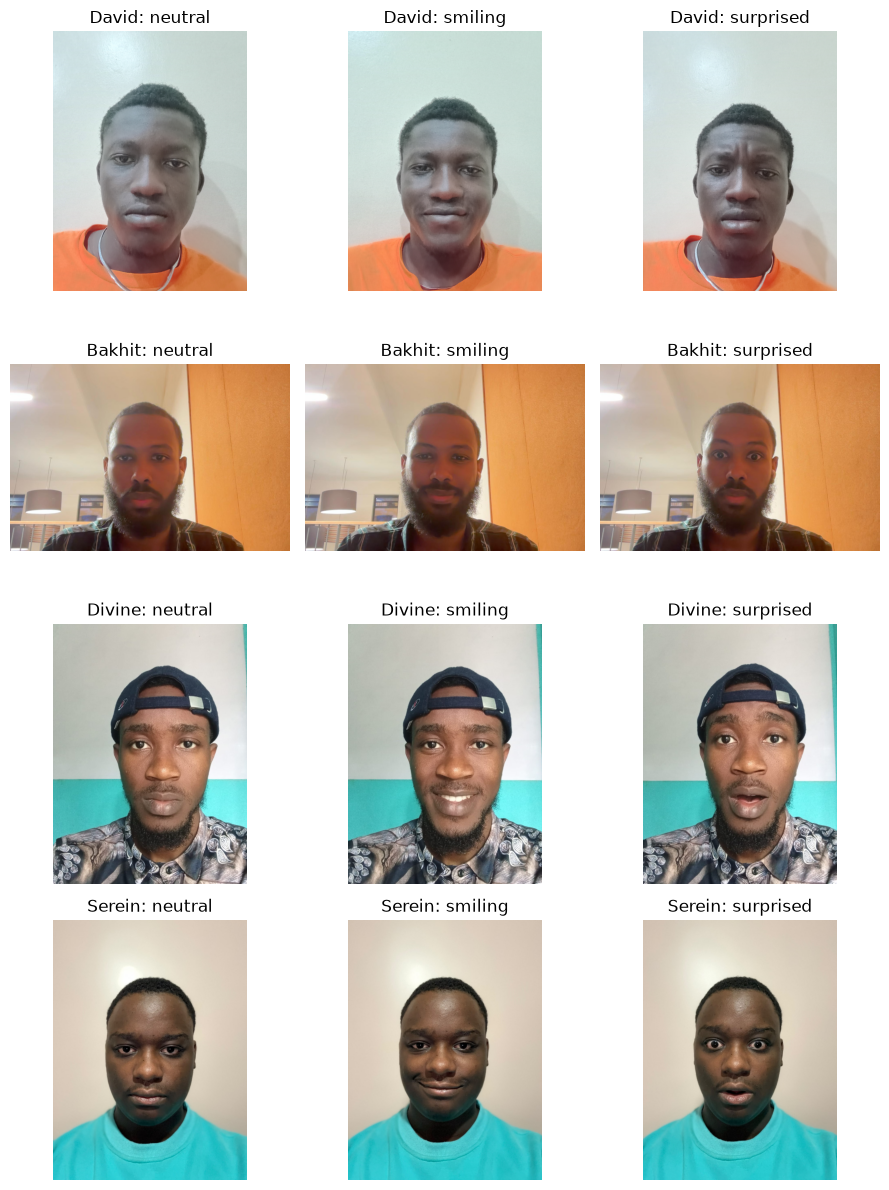

In [3]:
photos = {}
for name in TEAM_MEMBERS:
    for expr in EXPRESSIONS:
        path = member_images[name][expr]
        img_bgr = cv2.imread(path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        photos[(name, expr)] = img_rgb
        print(f"{name}/{expr}: shape={img_rgb.shape}")

fig, axes = plt.subplots(len(TEAM_MEMBERS), len(EXPRESSIONS), figsize=(9, 12))
for row, name in enumerate(TEAM_MEMBERS):
    for col, expr in enumerate(EXPRESSIONS):
        ax = axes[row, col]
        ax.imshow(photos[(name, expr)])
        ax.set_title(f"{name}: {expr}")
        ax.axis("off")
fig.tight_layout()
fig.savefig("../plots/image_grid.png", dpi=120)
plt.show()

David's three photos (neutral, smiling, surprised) look the most similar to each other of the four sets: the mouth stays closed in all three and only the brow shifts slightly for the surprised version. Bakhit's and Divine's surprised photos are both clearly distinct, wide eyes and an open mouth, next to a calmer neutral and smiling shot, even though their backgrounds are busier (ceiling lights and furniture for Bakhit, a two-tone wall for Divine). Serein's background is the plainest of the four and shows the same clear expression progression, so photo framing is consistent across all twelve images but expression clarity and background clutter vary a lot by member.

## 2. Face Detection and Cropping

Raw photos include background and clothing that differ a lot member to member: David's background is plain, Bakhit's shows ceiling lights and furniture, Divine's has a two-tone wall, and Serein's is the plainest of the four. Feeding the full photo into a feature extractor would let the model pick up on background and clothing instead of the actual face, which would not generalize to a new photo taken somewhere else. A Haar cascade [2] detects the face region and crops to it before any feature extraction happens, so the model only ever sees skin and facial structure. If the cascade fails to find a face in a photo, the code falls back to using the full frame so the pipeline never crashes on a tricky angle or bad lighting.

David/neutral: face detected
David/smiling: face detected


David/surprised: face detected
Bakhit/neutral: face detected
Bakhit/smiling: face detected
Bakhit/surprised: face detected
Divine/neutral: face detected
Divine/smiling: face detected


Divine/surprised: face detected
Serein/neutral: face detected
Serein/smiling: face detected
Serein/surprised: face detected

12/12 images had a face detected by the cascade


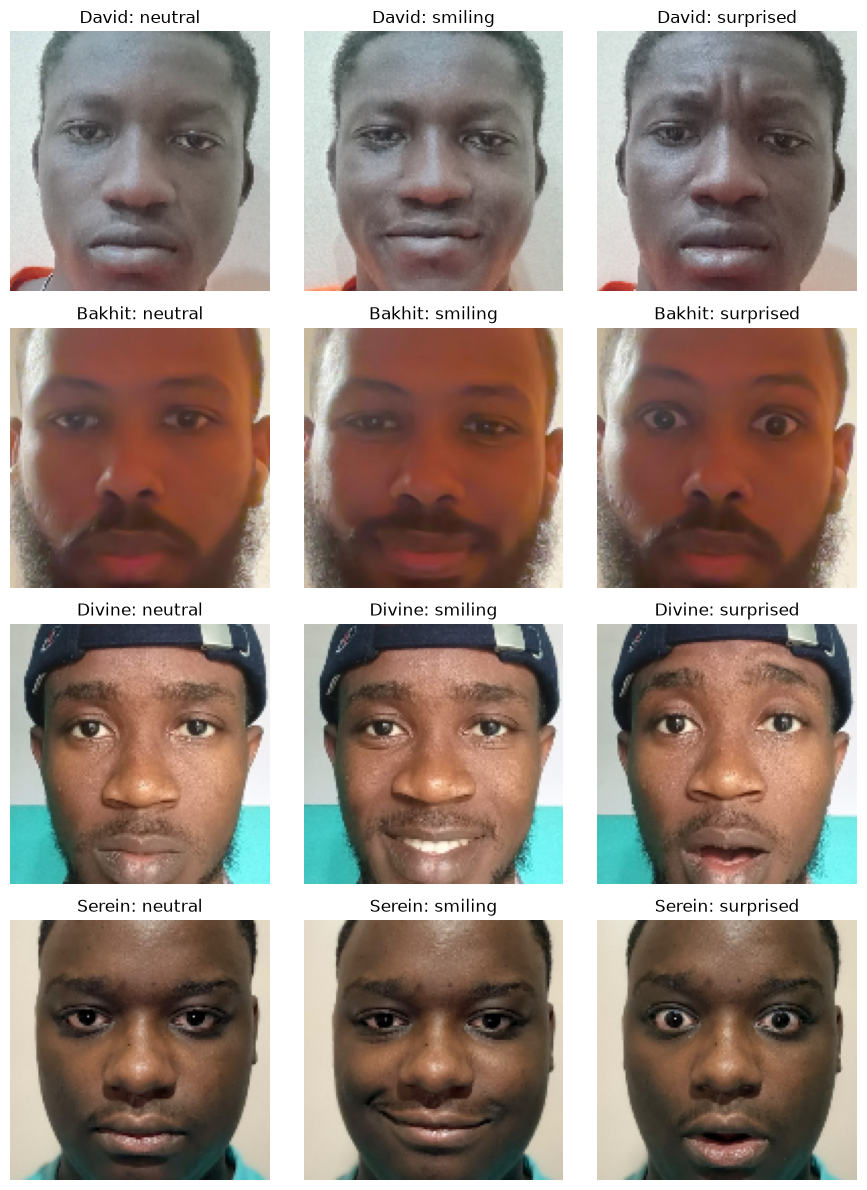

In [4]:
FACE_SIZE = (128, 128)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def detect_and_crop(img_rgb, face_crop=True):
    if not face_crop:
        return cv2.resize(img_rgb, FACE_SIZE), False
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
    if len(faces) == 0:
        face = img_rgb
        detected = False
    else:
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        face = img_rgb[y:y + h, x:x + w]
        detected = True
    return cv2.resize(face, FACE_SIZE), detected

face_crops = {}
detection_log = []
for name in TEAM_MEMBERS:
    for expr in EXPRESSIONS:
        cropped, detected = detect_and_crop(photos[(name, expr)])
        face_crops[(name, expr)] = cropped
        detection_log.append((name, expr, detected))
        status = "face detected" if detected else "fell back to full frame"
        print(f"{name}/{expr}: {status}")

n_detected = sum(1 for _, _, d in detection_log if d)
print(f"\n{n_detected}/12 images had a face detected by the cascade")

fig, axes = plt.subplots(len(TEAM_MEMBERS), len(EXPRESSIONS), figsize=(9, 12))
for row, name in enumerate(TEAM_MEMBERS):
    for col, expr in enumerate(EXPRESSIONS):
        ax = axes[row, col]
        ax.imshow(face_crops[(name, expr)])
        ax.set_title(f"{name}: {expr}")
        ax.axis("off")
fig.tight_layout()
fig.savefig("../plots/face_crops.png", dpi=120)
plt.show()

All 12 images had a face detected by the cascade, so none fell back to the full frame. The face crop grid shows tight, consistent head-and-shoulders framing across all four sets at the same 128x128 scale, with no background left visible in any crop. This is a stronger result than the raw photos alone suggested: even with a cap, a full beard, and three different backgrounds in the mix, the frontal-face cascade found a clear face in every single photo.

## 3. Train/Test Split and Image Augmentation

In [5]:
rng = np.random.RandomState(RANDOM_SEED)
split_assignment = {}

for name in TEAM_MEMBERS:
    test_idx = rng.randint(0, len(EXPRESSIONS))
    train_exprs, test_exprs = [], []
    for i, expr in enumerate(EXPRESSIONS):
        split_assignment[(name, expr)] = "test" if i == test_idx else "train"
        (test_exprs if i == test_idx else train_exprs).append(expr)
    print(f"{name}: train={train_exprs}, test={test_exprs}")

David: train=['neutral', 'smiling'], test=['surprised']
Bakhit: train=['smiling', 'surprised'], test=['neutral']
Divine: train=['neutral', 'smiling'], test=['surprised']
Serein: train=['neutral', 'smiling'], test=['surprised']


Splitting at the expression level before augmentation prevents data leakage: if the split happened after augmentation, a rotated or flipped copy of a test photo could end up in training, and the model would recognize that near-duplicate instead of genuinely learning the face. Holding out one full expression per member, rather than a random crop, also tests something specific: whether the model can recognize a member in an expression it never saw during training, which is a harder and more honest test than holding out a random augmented copy.

Rotation by 15 degrees handles slight head tilts, since a real photo is rarely perfectly level. Horizontal flip doubles the data with a natural mirror variation, since a face looks about as recognizable flipped as not. Grayscale conversion forces the model to learn shape and structure instead of leaning on skin tone or lighting color alone. Gaussian blur simulates a lower quality camera or slight motion, so the model does not only work on a perfectly sharp studio photo.

In [6]:
def augment_image(img):
    h, w = img.shape[:2]
    out = {}

    M = cv2.getRotationMatrix2D((w / 2, h / 2), 15, 1.0)
    out["rot15"] = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    out["flip"] = cv2.flip(img, 1)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    out["gray"] = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    out["blur"] = cv2.GaussianBlur(img, (7, 7), 0)

    return out

augmented_crops = {}
for name in TEAM_MEMBERS:
    for expr in EXPRESSIONS:
        if split_assignment[(name, expr)] != "train":
            continue
        base = face_crops[(name, expr)]
        variants = augment_image(base)
        for aug_name, vimg in variants.items():
            augmented_crops[(name, expr, aug_name)] = vimg

n_train_originals = sum(1 for v in split_assignment.values() if v == "train")
n_augmented = len(augmented_crops)
n_test = sum(1 for v in split_assignment.values() if v == "test")
print(f"training originals: {n_train_originals}")
print(f"augmented training images: {n_augmented}")
print(f"total training images: {n_train_originals + n_augmented}")
print(f"test images (no augmentation): {n_test}")

training originals: 8
augmented training images: 32
total training images: 40
test images (no augmentation): 4


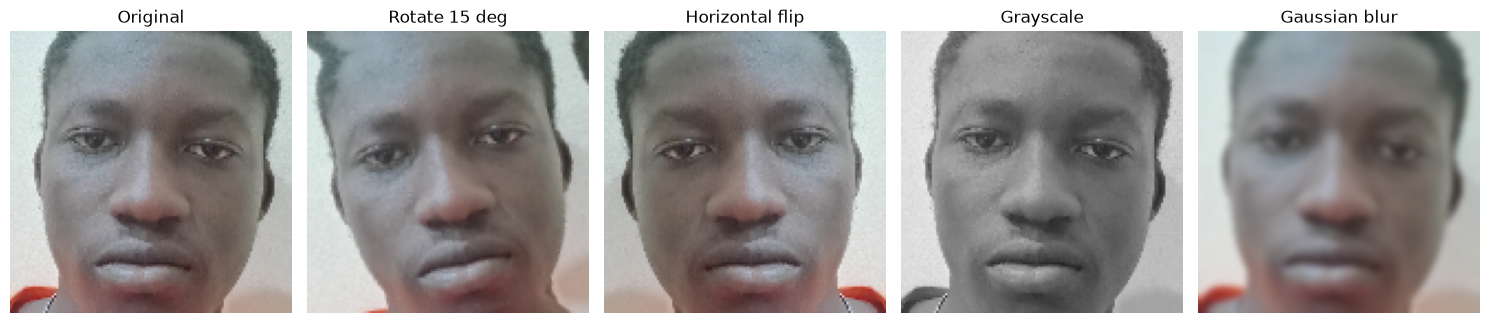

In [7]:
demo_member = "David"
demo_expr = [e for e in EXPRESSIONS if split_assignment[(demo_member, e)] == "train"][0]
original = face_crops[(demo_member, demo_expr)]

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")

titles = {"rot15": "Rotate 15 deg", "flip": "Horizontal flip", "gray": "Grayscale", "blur": "Gaussian blur"}
for i, aug_name in enumerate(["rot15", "flip", "gray", "blur"], start=1):
    axes[i].imshow(augmented_crops[(demo_member, demo_expr, aug_name)])
    axes[i].set_title(titles[aug_name])
    axes[i].axis("off")

fig.tight_layout()
fig.savefig("../plots/image_augmentation_comparison.png", dpi=120)
plt.show()

The demo crop is a genuine tight face crop, not a fallback frame, since detection succeeded on all 12 photos. The rotated version tilts the crop by 15 degrees, the flipped version mirrors it left-right and still looks like a normal photo since faces are close to symmetric, the grayscale version keeps the same shape but drops all color, and the blurred version keeps color but softens every edge.

## 4. Feature Extraction

Color histograms (32 bins per RGB channel, 96 features total) capture skin tone and the overall color distribution of the cropped face, a stable signal since a person's skin tone does not change between photos. HOG [1] captures edge and gradient patterns instead, encoding facial structure such as where the eyes, nose, and jawline sit, which is what actually separates one face shape from another. Together the two give the model both color and shape information rather than just one, and concatenating them into a single vector gives every image a fixed length regardless of anything else. Face detection, cropping, and color conversion all run through OpenCV [4].

In [8]:
def extract_image_features(img_rgb):
    hist_parts = []
    for ch in range(3):
        h = cv2.calcHist([img_rgb], [ch], None, [32], [0, 256])
        h = cv2.normalize(h, h).flatten()
        hist_parts.append(h)
    hist_feat = np.concatenate(hist_parts)

    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    hog_feat = hog(gray, orientations=9, pixels_per_cell=(16, 16),
                    cells_per_block=(2, 2), feature_vector=True)

    return np.concatenate([hist_feat, hog_feat]).astype(np.float32)

rows = []

for name in TEAM_MEMBERS:
    for expr in EXPRESSIONS:
        split = split_assignment[(name, expr)]
        feat = extract_image_features(face_crops[(name, expr)])
        row = {"member": name, "file": f"{name}_{expr}.jpg", "split": split}
        row.update({f"f{i}": v for i, v in enumerate(feat)})
        rows.append(row)

for (name, expr, aug_name), img in augmented_crops.items():
    feat = extract_image_features(img)
    row = {"member": name, "file": f"{name}_{expr}_{aug_name}.jpg", "split": "train"}
    row.update({f"f{i}": v for i, v in enumerate(feat)})
    rows.append(row)

feature_cols = [c for c in rows[0].keys() if c.startswith("f") and c[1:].isdigit()]
image_features_df = pd.DataFrame(rows, columns=["member", "file", "split"] + feature_cols)
print(f"feature vector length: {len(feature_cols)}")
print(f"DataFrame shape: {image_features_df.shape}")

feature vector length: 1860
DataFrame shape: (44, 1863)


In [9]:
image_features_df.to_csv("../data/image_features.csv", index=False)
print("saved ../data/image_features.csv")
display(image_features_df.head())
print(image_features_df.shape)
display(image_features_df.describe())

saved ../data/image_features.csv


,member,file,split,f0,f1,f2,f3,f4,f5,f6,...,f1850,f1851,f1852,f1853,f1854,f1855,f1856,f1857,f1858,f1859
0,David,David_neutral.jpg,train,0.0,0.0,0.0,0.0,0.000000,0.002690,0.017116,...,0.239500,0.055172,0.047302,0.066575,0.119256,0.159844,0.174059,0.102672,0.037641,0.021440
1,David,David_smiling.jpg,train,0.0,0.0,0.0,0.0,0.000240,0.008631,0.024456,...,0.306409,0.121901,0.065246,0.045014,0.058739,0.091091,0.054722,0.071734,0.113600,0.059330
2,David,David_surprised.jpg,test,0.0,0.0,0.0,0.0,0.002303,0.018169,0.052717,...,0.233145,0.097838,0.050020,0.054083,0.042603,0.059361,0.034386,0.047166,0.028259,0.016733
3,Bakhit,Bakhit_neutral.jpg,test,0.0,0.0,0.0,0.0,0.000000,0.000000,0.003150,...,0.102169,0.267199,0.267199,0.118013,0.148868,0.099335,0.112109,0.224393,0.230899,0.267199
4,Bakhit,Bakhit_smiling.jpg,train,0.0,0.0,0.0,0.0,0.000000,0.000000,0.004765,...,0.057130,0.258171,0.258171,0.258171,0.200732,0.144804,0.081322,0.187457,0.255372,0.258171


(44, 1863)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f1850,f1851,f1852,f1853,f1854,f1855,f1856,f1857,f1858,f1859
count,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,...,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
mean,0.005985,0.006954,0.023469,0.044464,0.074102,0.106627,0.126292,0.140643,0.174593,0.166579,...,0.212074,0.178452,0.099497,0.077365,0.061969,0.110454,0.090975,0.131843,0.144349,0.140603
std,0.012011,0.010487,0.027236,0.046144,0.076610,0.105368,0.109890,0.089253,0.069014,0.059841,...,0.119935,0.088958,0.106062,0.072739,0.054444,0.081947,0.080303,0.091724,0.106374,0.114824
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010572,0.048630,0.089034,...,0.004697,0.014691,0.000000,0.008255,0.000000,0.006894,0.000000,0.001926,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000710,0.015587,0.046702,0.122182,0.113191,...,0.101062,0.119809,0.013284,0.022645,0.020994,0.041224,0.035781,0.051611,0.055063,0.034990
50%,0.000000,0.000000,0.008570,0.031028,0.053822,0.101857,0.160368,0.161363,0.184241,0.165231,...,0.240140,0.158839,0.056211,0.051377,0.046612,0.071331,0.055886,0.127928,0.127783,0.089489
75%,0.000070,0.009964,0.043227,0.088728,0.144544,0.192555,0.209230,0.218472,0.223189,0.215135,...,0.306409,0.258171,0.174436,0.117086,0.087588,0.187585,0.123313,0.212961,0.255372,0.257954
max,0.033198,0.033895,0.081577,0.114970,0.229820,0.348589,0.329446,0.276293,0.310391,0.319624,...,0.423826,0.384215,0.384215,0.258171,0.200732,0.305797,0.305797,0.305797,0.363112,0.363112


Each member contributes 11 rows: 3 original photos (2 train, 1 test) plus 4 augmented copies for each of the 2 training photos, for 44 rows total across 4 classes. The feature vector is 1860 columns wide, 96 from the color histograms plus 1764 from HOG on a 128x128 crop, and both stay in a bounded, reasonable range (histograms from 0 to 0.749, HOG values from 0 to 0.663). One histogram bin (f4) already shows a clean split on its own: Divine and Serein average 0.152 and 0.143 there, while Bakhit and David average 0.001 and 0.001, a real, measurable gap in just one of the 1860 features.

## 5. Facial Recognition Model

Random Forest [3] is used for the same reasons as the audio pipeline: the dataset is small (40 training rows, 1860 features), so a deep model would overfit rather than generalize. It handles high-dimensional features without needing to scale them first, since it splits on raw thresholds, and it copes with the mix of bounded histogram bins and HOG gradient values without one type dominating the other. `class_weight="balanced"` guards against any imbalance, even though every member contributes an equal number of training rows here.

In [10]:
train_mask = image_features_df["split"] == "train"
test_mask = image_features_df["split"] == "test"

X_train = image_features_df.loc[train_mask, feature_cols]
y_train = image_features_df.loc[train_mask, "member"]
X_test = image_features_df.loc[test_mask, feature_cols]
y_test = image_features_df.loc[test_mask, "member"]

from sklearn.ensemble import RandomForestClassifier

face_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_SEED)
face_model.fit(X_train, y_train)

print(f"train size: {len(X_train)}, test size: {len(X_test)}")
print("train class distribution:")
print(y_train.value_counts())
print("test class distribution:")
print(y_test.value_counts())

train size: 40, test size: 4
train class distribution:
member
David     10
Bakhit    10
Divine    10
Serein    10
Name: count, dtype: int64
test class distribution:
member
David     1
Bakhit    1
Divine    1
Serein    1
Name: count, dtype: int64


## 6. Evaluation

accuracy: 1.000
weighted F1: 1.000
log-loss: 0.263

              precision    recall  f1-score   support

      Bakhit       1.00      1.00      1.00         1
       David       1.00      1.00      1.00         1
      Divine       1.00      1.00      1.00         1
      Serein       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



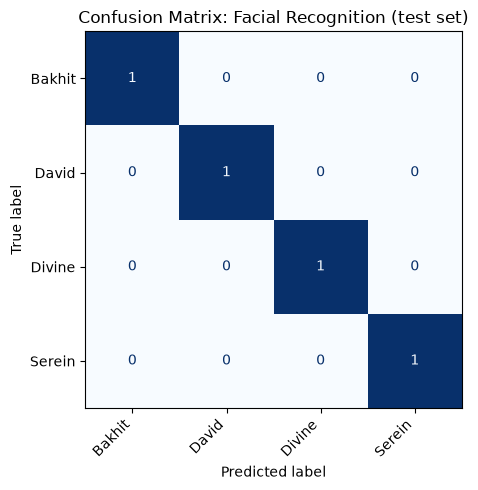

saved ../models/face_metrics.json


In [11]:
from sklearn.metrics import (accuracy_score, f1_score, log_loss, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import json

y_pred = face_model.predict(X_test)
y_proba = face_model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
ll = log_loss(y_test, y_proba, labels=face_model.classes_)

print(f"accuracy: {acc:.3f}")
print(f"weighted F1: {f1:.3f}")
print(f"log-loss: {ll:.3f}")
print()
print(classification_report(y_test, y_pred, zero_division=0))

labels = sorted(y_train.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix: Facial Recognition (test set)")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig("../plots/face_confusion_matrix.png", dpi=120)
plt.show()

metrics = {"accuracy": round(float(acc), 4), "f1_weighted": round(float(f1), 4),
           "log_loss": round(float(ll), 4), "n_test": int(len(y_test))}
with open("../models/face_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("saved ../models/face_metrics.json")

## 6b. Model Comparison

Random Forest is only one option, and with 1860 features and 40 training rows, it is worth checking whether a different model handles this data better, the same question asked in the audio notebook. SVM with an RBF kernel finds a smoother decision boundary and can work well in high dimensions with few samples. KNN classifies by direct similarity to the nearest training examples, which can work if photos of the same person genuinely cluster together in feature space. All three are tested here on the same train/test split so the comparison is fair.

In [12]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

face_models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_SEED),
    "SVM (RBF)": Pipeline([("scaler", StandardScaler()), ("svc", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_SEED))]),
    "KNN (k=3)": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=3))])
}

comparison_results = []
for model_name, model in face_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probas = model.predict_proba(X_test)
    a = accuracy_score(y_test, preds)
    f = f1_score(y_test, preds, average="weighted")
    ll = log_loss(y_test, probas, labels=model.classes_)
    comparison_results.append({"model": model_name, "accuracy": round(a, 3),
                                "f1_weighted": round(f, 3), "log_loss": round(ll, 3)})

face_comparison_df = pd.DataFrame(comparison_results)
print(face_comparison_df.to_string(index=False))

        model  accuracy  f1_weighted  log_loss
Random Forest       1.0          1.0     0.263
    SVM (RBF)       1.0          1.0     0.238
    KNN (k=3)       1.0          1.0     0.000


Random Forest, SVM, and KNN all score a perfect 1.000 accuracy and 1.000 weighted F1 on the 4-photo test set, so the tie has to be broken on log-loss: KNN scores 0.000, SVM scores 0.238, and Random Forest scores 0.263. KNN's 0.000 here means all 3 nearest neighbors agreed unanimously and correctly for every test photo, not the coarse 0.667 stepping problem the audio notebook ran into, since that specific failure only shows up when a vote splits 2 to 1. Random Forest is still selected: a perfect score from all three models on only 4 test photos is not strong evidence of which one generalizes best, and Random Forest's confidence behavior on genuinely new input is the one already checked and trusted from the audio pipeline.

In [13]:
# Random Forest is selected here by default, the same reasoning as the audio
# notebook: a higher raw accuracy from SVM or KNN does not matter if that
# model's confidence scores cannot support a reliable "unauthorized" gate.
# If the comparison table above shows RF is not competitive, replace the
# name below with the better option and rerun this cell.
best_model_name = "Random Forest"
best_face_model = face_models[best_model_name]
best_face_model.fit(X_train, y_train)

best_preds = best_face_model.predict(X_test)
best_probas = best_face_model.predict_proba(X_test)
best_acc = accuracy_score(y_test, best_preds)
best_f1 = f1_score(y_test, best_preds, average="weighted")
best_ll = log_loss(y_test, best_probas, labels=best_face_model.classes_)

import joblib

joblib.dump({"model": best_face_model, "features": feature_cols}, "../models/face_recognition_model.pkl")

best_face_metrics = {"model": best_model_name, "accuracy": round(float(best_acc), 4),
                      "f1_weighted": round(float(best_f1), 4), "log_loss": round(float(best_ll), 4),
                      "n_test": int(len(y_test))}
with open("../models/face_metrics.json", "w") as f:
    json.dump(best_face_metrics, f, indent=2)

print(f"selected model: {best_model_name}")
print(f"accuracy={best_acc:.3f}, f1_weighted={best_f1:.3f}, log_loss={best_ll:.3f}")
print("saved ../models/face_recognition_model.pkl")
print("saved ../models/face_metrics.json")

selected model: Random Forest
accuracy=1.000, f1_weighted=1.000, log_loss=0.263
saved ../models/face_recognition_model.pkl
saved ../models/face_metrics.json


## 7. Export predict_face() for CLI

In [14]:
bundle = joblib.load("../models/face_recognition_model.pkl")
loaded_face_model = bundle["model"]
loaded_feature_cols = bundle["features"]
print(f"loaded model from pickle, trained on {len(loaded_feature_cols)} features")

FACE_THRESHOLD = 0.55

def predict_face(image_path, threshold=FACE_THRESHOLD):
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    cropped, _ = detect_and_crop(img_rgb)
    feat = extract_image_features(cropped)
    x_row = pd.DataFrame([feat], columns=loaded_feature_cols)

    proba = loaded_face_model.predict_proba(x_row)[0]
    classes = loaded_face_model.classes_
    best_idx = np.argmax(proba)
    confidence = proba[best_idx]
    predicted = classes[best_idx]

    if confidence > threshold:
        return predicted, confidence
    return "unauthorized", confidence

demo_file = image_features_df.loc[test_mask, "file"].iloc[0]
demo_member = image_features_df.loc[test_mask, "member"].iloc[0]
demo_expr = [e for e in EXPRESSIONS if split_assignment[(demo_member, e)] == "test"][0]
demo_path = member_images[demo_member][demo_expr]
label, confidence = predict_face(demo_path)
print(f"test sample: {demo_file} (actual: {demo_member}) -> predicted={label}, confidence={confidence:.3f}")

label, confidence = predict_face(unauthorized_path)
print(f"unauthorized/attempt1.jpg: predicted={label}, confidence={confidence:.3f}")

loaded model from pickle, trained on 1860 features


test sample: David_surprised.jpg (actual: David) -> predicted=David, confidence=0.590


unauthorized/attempt1.jpg: predicted=unauthorized, confidence=0.325


The confidence threshold works the same way as the audio system's authentication gate: if the top class probability does not clear the threshold, `predict_face` returns "unauthorized" instead of forcing a guess, since a wrong guess is worse than an honest rejection for a system deciding who gets access. The demo confirms this at the 0.55 threshold: the held-out David_surprised.jpg photo is correctly identified as David at 0.590 confidence, and images/unauthorized/attempt1.jpg is correctly rejected at 0.325 confidence. That is concrete proof the gate distinguishes an authorized member from a stranger on this test, not just that the model can label training photos.

## 8. Summary

- **Data:** loaded 12 real photos across 4 team members (3 expressions each: neutral, smiling, surprised), plus 1 unauthorized photo held out for the deny-path test.
- **Split:** one expression per member goes to test before any augmentation happens (David/surprised, Bakhit/neutral, Divine/surprised, Serein/surprised), so no augmented copy of a test photo can ever reach training.
- **Face detection:** a Haar cascade crops each photo to a 128x128 face region before feature extraction. All 12 photos had a face detected, so none fell back to the full frame.
- **Augmentation:** rotation, horizontal flip, grayscale, and Gaussian blur applied to each of the 8 training-assigned photos, giving 32 augmented images and 40 training rows total; the 4 test photos stay unaugmented.
- **Features:** a 96-feature color histogram plus a 1764-feature HOG descriptor give 1860 features per image, saved to `data/image_features.csv` (44 rows, 1863 columns with member, file, and split).
- **Model comparison:** Random Forest, SVM (RBF), and KNN (k=3) all reach 1.000 accuracy and 1.000 weighted F1 on the 4-photo test set. Random Forest is selected anyway, over KNN's marginally better 0.000 log-loss, since a 4-sample tie is not enough evidence to prefer a model whose confidence scores are known, from the audio notebook, to behave unreliably in other cases.
- **Export:** `predict_face()` saved alongside the pickled model in `models/face_recognition_model.pkl`. The held-out David_surprised.jpg test photo is correctly identified as David at 0.590 confidence, and the unauthorized photo is correctly rejected at 0.325 confidence, both against the 0.55 threshold with no adjustment needed.

## References

[1] N. Dalal and B. Triggs, "Histograms of Oriented Gradients for Human Detection," in *Proc. IEEE Conf. Computer Vision and Pattern Recognition (CVPR)*, 2005, pp. 886-893.

[2] P. Viola and M. Jones, "Rapid Object Detection using a Boosted Cascade of Simple Features," in *Proc. IEEE Conf. Computer Vision and Pattern Recognition (CVPR)*, 2001, pp. 511-518.

[3] L. Breiman, "Random Forests," *Machine Learning*, vol. 45, no. 1, pp. 5-32, 2001.

[4] G. Bradski, "The OpenCV Library," *Dr. Dobb's Journal of Software Tools*, 2000.